Working directory: C:\Users\naban\Downloads\Hackathon\GenTA\project
Outputs folder contents: ['.ipynb_checkpoints', 'embeddings.npy', 'embeddings_index.csv', 'embedding_stats.txt', 'heatmap.png', 'query_0_neighbors.png', 'query_1_neighbors.png', 'query_2_neighbors.png', 'similarity.npy', 'topk.csv', 'tsne.png']


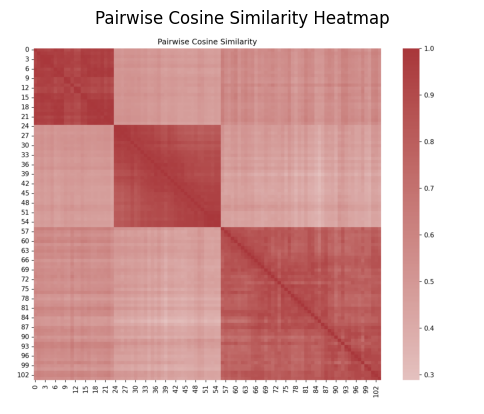

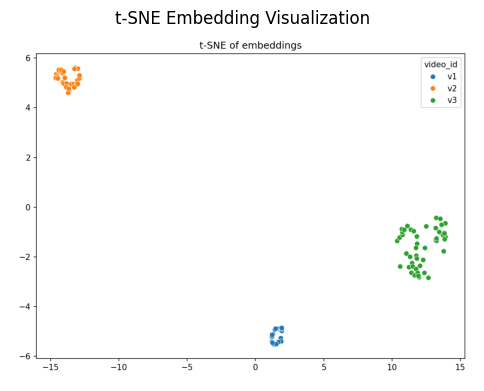


Index sample:


,idx,video_id,file_path,timestamp_s,md5
0,0,v1,data\frames\video1\v1_0000000.jpg,0.0,f32437bbdf66209efe24d1d6562ef9b2
1,1,v1,data\frames\video1\v1_0001500.jpg,1.5,1db245635972243b754048e55c373e5b
2,2,v1,data\frames\video1\v1_0003000.jpg,3.0,e3e9ea6779ac06f273792ca0ced30679
3,3,v1,data\frames\video1\v1_0004500.jpg,4.5,d3c6e3e16b4dbb1cc344ea22a6f1fae8
4,4,v1,data\frames\video1\v1_0006000.jpg,6.0,851aad95d052597d5ac97f017813b813



Top-k sample:


,query_idx,neighbor_idx,score,rank
0,0,8,0.972044,1
1,0,6,0.969041,2
2,0,20,0.963194,3
3,0,22,0.962183,4
4,0,18,0.960206,5



Selected queries: [0, 24, 56]

=== Query idx: 0 ===


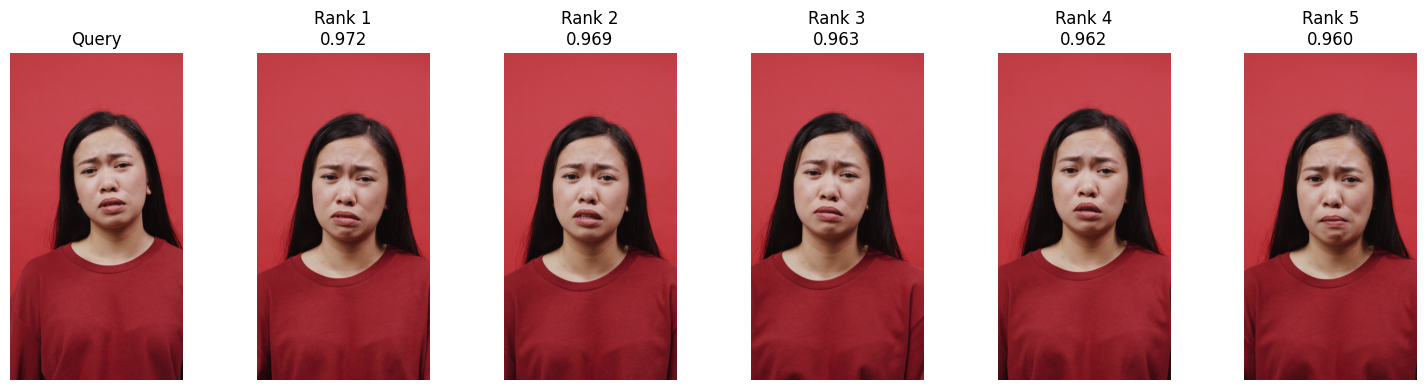


=== Query idx: 24 ===


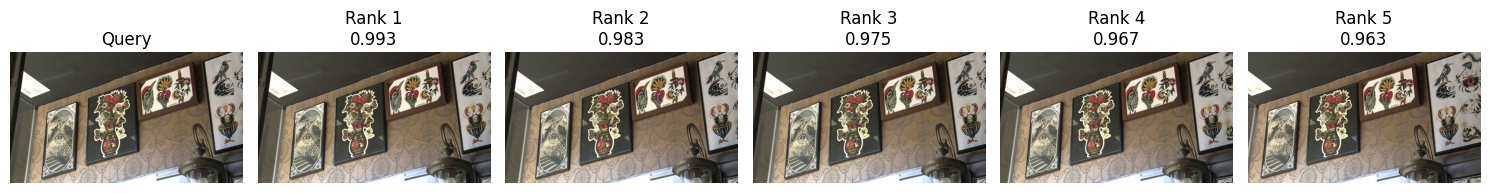


=== Query idx: 56 ===


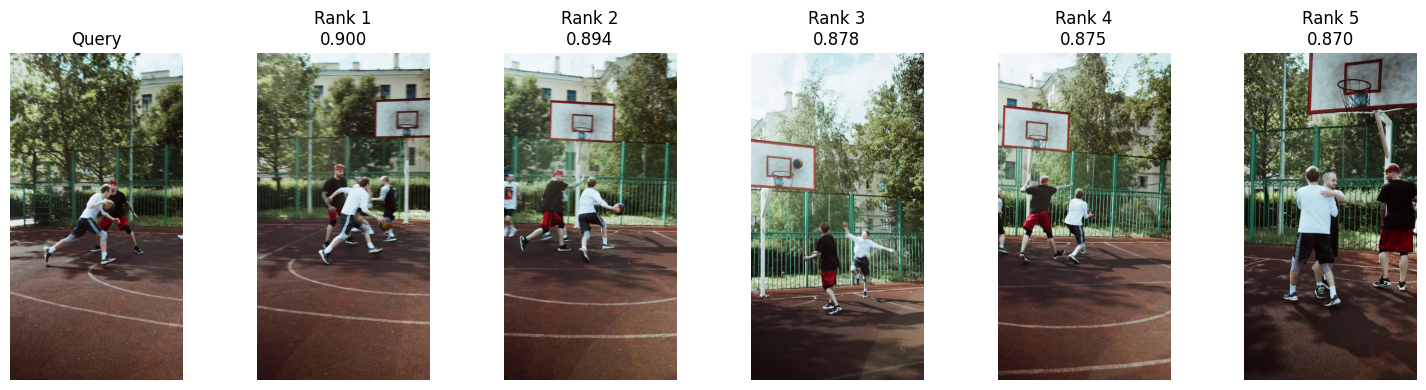

In [1]:
# ===============================
# Mini GACS Interactive Inspection
# ===============================

import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------
# 1. Basic sanity checks
# -------------------------------

print("Working directory:", os.getcwd())
print("Outputs folder contents:", os.listdir("outputs"))

assert os.path.exists("outputs/embeddings_index.csv"), "Missing embeddings_index.csv"
assert os.path.exists("outputs/topk.csv"), "Missing topk.csv"
assert os.path.exists("outputs/heatmap.png"), "Missing heatmap.png"
assert os.path.exists("outputs/tsne.png"), "Missing tsne.png"

# -------------------------------
# 2. Display saved visualizations
# -------------------------------

plt.figure(figsize=(6,6))
plt.imshow(Image.open("outputs/heatmap.png"))
plt.title("Pairwise Cosine Similarity Heatmap")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(Image.open("outputs/tsne.png"))
plt.title("t-SNE Embedding Visualization")
plt.axis("off")
plt.show()

# -------------------------------
# 3. Load metadata
# -------------------------------

idx = pd.read_csv("outputs/embeddings_index.csv")
topk = pd.read_csv("outputs/topk.csv")

print("\nIndex sample:")
display(idx.head())

print("\nTop-k sample:")
display(topk.head())

# -------------------------------
# 4. Function: Show Query + Neighbors
# -------------------------------

def show_query_with_neighbors(query_idx):
    query_row = idx[idx["idx"] == query_idx]
    if len(query_row) == 0:
        print(f"Query idx {query_idx} not found.")
        return
    
    query_path = query_row["file_path"].values[0]
    
    neighbors = (
        topk[topk["query_idx"] == query_idx]
        .sort_values("rank")
        .head(5)
    )

    paths = [query_path] + [
        idx.loc[idx["idx"] == r["neighbor_idx"], "file_path"].values[0]
        for _, r in neighbors.iterrows()
    ]

    plt.figure(figsize=(15,4))
    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        plt.subplot(1,6,i+1)
        plt.imshow(img)
        plt.axis("off")

        if i == 0:
            plt.title("Query")
        else:
            score = neighbors.iloc[i-1]["score"]
            plt.title(f"Rank {i}\n{score:.3f}")

    plt.tight_layout()
    plt.show()

# -------------------------------
# 5. Automatically select up to 3 queries
# -------------------------------

queries = []
for vid in idx["video_id"].unique()[:3]:
    sub = idx[idx["video_id"] == vid]
    if len(sub) > 0:
        queries.append(int(sub.iloc[0]["idx"]))

if not queries:
    queries = [0]

print("\nSelected queries:", queries)

for q in queries:
    print(f"\n=== Query idx: {q} ===")
    show_query_with_neighbors(q)